# Bonus: Other machine learning approaches for classification

## Multiclass Support Vector Machine (SVM) using the features dataset

In [6]:
import os
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

random_seed = 10
random.seed(random_seed)
np.random.seed(random_seed)

## Data preparation

### Load data

In [7]:
data = pd.read_csv(os.path.join(".", "data", "features_30_sec.csv"))

X = data.iloc[:, 2:-1].values  # All feature columns
y = data.iloc[:, -1].values     # Label column

print(f"Dataset loaded:\n")
print(f"Total samples:     {len(X)}")
print(f"Features:          {X.shape[1]}")
print(f"Classes:           {sorted(set(y))}")
print(f"Samples per class: {pd.Series(y).value_counts().to_dict()}")


Dataset loaded:

Total samples:     1000
Features:          57
Classes:           ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Samples per class: {'blues': 100, 'classical': 100, 'country': 100, 'disco': 100, 'hiphop': 100, 'jazz': 100, 'metal': 100, 'pop': 100, 'reggae': 100, 'rock': 100}


### Split into training and test datasets

In [8]:
# Stratified train/test split to ensure balanced class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=random_seed, 
    stratify=y
)

print(f"Dataset split (stratified):\n")
print(f"Training:   {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Training class distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test class distribution:     {pd.Series(y_test).value_counts().to_dict()}")


Dataset split (stratified):

Training:   800 samples (80.0%)
Test:       200 samples (20.0%)
Training class distribution: {'reggae': 80, 'jazz': 80, 'country': 80, 'disco': 80, 'pop': 80, 'hiphop': 80, 'blues': 80, 'metal': 80, 'classical': 80, 'rock': 80}
Test class distribution:     {'blues': 20, 'metal': 20, 'country': 20, 'rock': 20, 'classical': 20, 'disco': 20, 'pop': 20, 'hiphop': 20, 'reggae': 20, 'jazz': 20}


## Have a look at the data
Before we start, let's take a look at the data. The cell below plots the correlation matrix between all the features included in the dataset and identifies the number of highly correlated pairs. This will inform whether applying PCA is likely to be helpful or might instead harm performance.

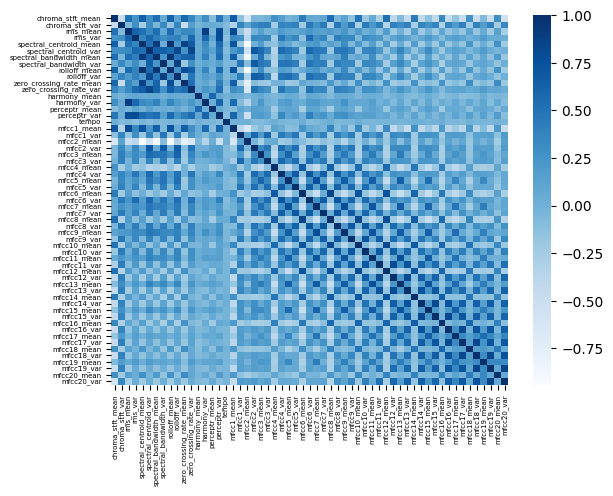

Number of features: 57
Highly correlated pairs (|r| > 0.8): 21


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

correlation_matrix = np.corrcoef(X_train_scaled.T)
ax = sns.heatmap(correlation_matrix, 
                 annot=False, 
                 cmap='Blues', 
                 xticklabels = np.array(data.columns[2:-1]), 
                 yticklabels = np.array(data.columns[2:-1]))

ax.tick_params(axis='both', labelsize=5)
plt.show()

high_corr_pairs = np.sum(np.abs(correlation_matrix) > 0.8) - X_train.shape[1]  # Exclude diagonal

print(f"Number of features: {X_train.shape[1]}")
print(f"Highly correlated pairs (|r| > 0.8): {high_corr_pairs // 2}")  # Divide by 2 for symmetry

The correlation matrix reveals clear patterns. This can be partly due to the structure of the dataset: the variables consist of the mean and variance of audio parameters for a given track. The grid pattern corresponds to variables in columns 17-57, which are the means and variances of 20 MFCC measures.

**What are MFCCs?**

MFCCs (Mel-frequency cepstral coefficients) are numerical features that describe the spectral properties of an audio signal. They are calculated through the following process ([ref](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum)):

1. The audio signal is divided into short time windows
2. A Fourier transform converts each window from the time domain to the frequency domain
3. The frequency spectrum is mapped onto the mel scale, which spaces frequencies according to human pitch perception (linear below 1000 Hz, logarithmic above)
4. The mel-scaled spectrum is converted to decibels (logarithm of power)
5. A discrete cosine transform (DCT) is applied to decorrelate the log mel-spectrum
6. The resulting coefficients are the MFCCs

The first MFCC typically represents the overall spectral energy, while subsequent coefficients capture increasingly fine spectral details ([ref](https://www.sciencedirect.com/topics/computer-science/mel-frequency-cepstral-coefficient)).

For this dataset, each audio track is represented by 20 MFCC mean values (the average coefficient values over the 30-second duration) and 20 MFCC variance values (how much each coefficient fluctuates over time). These 40 MFCC-related features constitute the majority of the 57 total features used for classification.

## Define pipelines
We're going to use three pipelines:
- SVM with no PCA
- SVM preceded by PCA with 90% variance explanation
- SVM preceded by PCA with 95% variance explanation

The PCA step leads to a reduction in data dimensionality, capturing the variables that are most responsible for the variance in the dataset.

In [10]:
pipelines = {
    'SVM_baseline': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(random_state=random_seed))
    ]),
    
    'SVM_with_PCA_90': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.90)),  # 90% variance
        ('svm', SVC(random_state=random_seed))
    ]),
    
    'SVM_with_PCA_95': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),  # 95% variance
        ('svm', SVC(random_state=random_seed))
    ]),
}

### Stratified k-Fold Cross Validation ($k=5$)
For cross-validation (CV), we split the full dataset into 5 "folds" with stratification, i.e. the distribution of the classes is maintained in each fold. The model is then tested with each fold being consecutively used as the validation dataset, while the other folds are used for training.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
cv_results = {}

for name, pipeline in pipelines.items():
    print(f"\nEvaluating {name}")
    
    start_time = time.time()

    # Perform 5-fold cross-validation
    scores = cross_val_score(
        pipeline, X_train, y_train, 
        cv=cv, 
        scoring='accuracy',
        n_jobs=-1
    )
    
    elapsed_time = time.time() - start_time

    cv_results[name] = {
        'cv_mean': scores.mean(),
        'cv_std': scores.std(),
        'cv_scores': scores,
        'time': elapsed_time
    }
    
    print(f"  CV Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
    print(f"  Fold scores: {[f'{s:.3f}' for s in scores]}")
    print(f"  Training time: {elapsed_time:.2f} seconds")




Evaluating SVM_baseline
  CV Accuracy: 0.710 ± 0.026
  Fold scores: ['0.719', '0.744', '0.713', '0.713', '0.662']
  Training time: 3.08 seconds

Evaluating SVM_with_PCA_90
  CV Accuracy: 0.670 ± 0.030
  Fold scores: ['0.681', '0.700', '0.669', '0.688', '0.613']
  Training time: 2.15 seconds

Evaluating SVM_with_PCA_95
  CV Accuracy: 0.700 ± 0.031
  Fold scores: ['0.706', '0.738', '0.700', '0.713', '0.644']
  Training time: 1.57 seconds


### Summary

In [13]:
df_cv = pd.DataFrame({
    name: {
        'Mean': f"{results['cv_mean']:.2f}",
        'Std': f"{results['cv_std']:.3f}",
        'Time (s)': f"{results['time']:.2f}"
    }
    for name, results in cv_results.items()
}).T
print(df_cv)


                 Mean    Std Time (s)
SVM_baseline     0.71  0.026     3.08
SVM_with_PCA_90  0.67  0.030     2.15
SVM_with_PCA_95  0.70  0.031     1.57


## Tuning hyperparameters
### Pipeline for tuning

In [19]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('svm', SVC(random_state=random_seed))
])

### Parameter grid

In [14]:
param_grid = {
    'pca__n_components': [0.85, 0.90, 0.95, 0.99],
    'svm__C': [1, 5, 10, 15, 20],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto']
}

print(f"\nSearching {len(param_grid['pca__n_components']) * len(param_grid['svm__C']) * len(param_grid['svm__kernel']) * len(param_grid['svm__gamma'])} combinations...")

# Grid search with cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)
print(f"Best CV score: {grid_search.best_score_:.3f}")



Searching 80 combinations...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best CV score: 0.738


### PCA analysis across the grid search
Let's check the trade-off between performance and dimensionality reduction for each variance threshold.

In [21]:
variance_thresholds = param_grid['pca__n_components']

for var_threshold in variance_thresholds:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    pca = PCA(n_components=var_threshold)
    pca.fit(X_train_scaled)
    
    # Get best score for this variance threshold
    mask = pd.DataFrame(grid_search.cv_results_)['param_pca__n_components'] == var_threshold
    best_score_for_threshold = pd.DataFrame(grid_search.cv_results_)[mask]['mean_test_score'].max()
    
    print(f"\nVariance: {var_threshold:.0%}")
    print(f"  Components: {pca.n_components_} (out of {X_train.shape[1]} original features)")
    print(f"  Reduction: {(1 - pca.n_components_/X_train.shape[1])*100:.1f}%")
    print(f"  Best CV score: {best_score_for_threshold:.4f}")


Variance: 85%
  Components: 16 (out of 57 original features)
  Reduction: 71.9%
  Best CV score: 0.6863

Variance: 90%
  Components: 23 (out of 57 original features)
  Reduction: 59.6%
  Best CV score: 0.7100

Variance: 95%
  Components: 33 (out of 57 original features)
  Reduction: 42.1%
  Best CV score: 0.7225

Variance: 99%
  Components: 46 (out of 57 original features)
  Reduction: 19.3%
  Best CV score: 0.7375


## Model evaluation on the test dataset

In [ ]:
# Get the best model
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy:            {test_accuracy:.3f}")
print(f"CV accuracy (for comparison): {grid_search.best_score_:.3f}")
print(f"Difference:                   {abs(test_accuracy - grid_search.best_score_):.3f}\n")

if abs(test_accuracy - grid_search.best_score_) < 0.05:
    print("CV and test scores are close (< 5% difference)")
else:
    print("Warning: Significant difference between CV and test scores")

# Classification report
print("\n" + "="*55)
print("Classification report:")
print("="*55)
print(classification_report(y_test, y_pred))

Test Set Accuracy           : 0.755
CV accuracy (for comparison): 0.738
Difference                  : 0.017

CV and test scores are close (< 5% difference)

Classification report:
              precision    recall  f1-score   support

       blues       0.84      0.80      0.82        20
   classical       0.86      0.95      0.90        20
     country       0.88      0.75      0.81        20
       disco       0.61      0.70      0.65        20
      hiphop       0.80      0.80      0.80        20
        jazz       0.75      0.75      0.75        20
       metal       0.79      0.95      0.86        20
         pop       0.81      0.65      0.72        20
      reggae       0.69      0.45      0.55        20
        rock       0.58      0.75      0.65        20

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.75       200
weighted avg       0.76      0.76      0.75       200



### Visualisation: confusion matrix

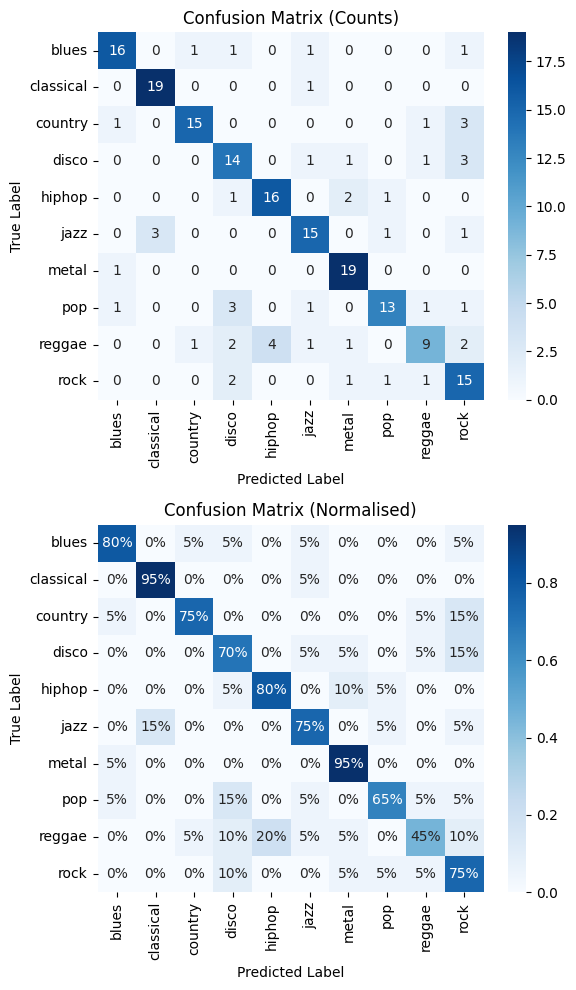

In [23]:
classes = sorted(set(y))

# Assemble confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,10))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=classes, yticklabels=classes)
ax1.set_title('Confusion Matrix (Counts)')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# Normalised (percentages)
sns.heatmap(cm_normalised, annot=True, fmt='.0%', cmap='Blues', ax=ax2,
            xticklabels=classes, yticklabels=classes)
ax2.set_title('Confusion Matrix (Normalised)')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


### Feature analysis with PCA


Number of components: 46
Total variance explained: 0.990

Variance explained by each component:
  PC1: 0.243
  PC2: 0.172
  PC3: 0.107
  PC4: 0.076
  PC5: 0.045
  PC6: 0.035
  PC7: 0.029
  PC8: 0.024
  PC9: 0.024
  PC10: 0.018

PCA analysis saved as 'pca_variance_analysis.png'


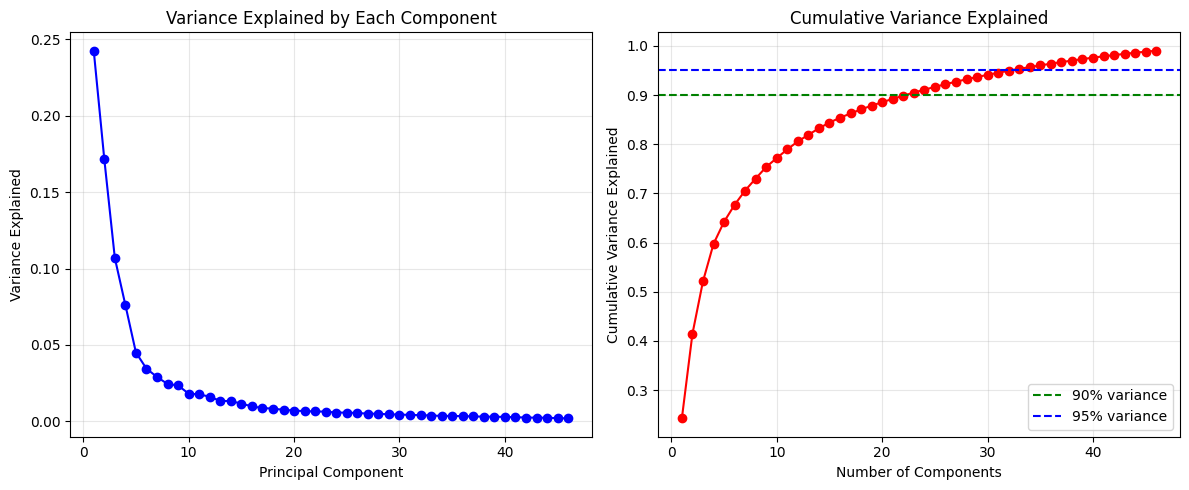

In [ ]:
# Get the PCA component from the best pipeline
pca = best_model.named_steps['pca']

print(f"\nNumber of components: {pca.n_components_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")
print(f"\nVariance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_[:10], 1):
    print(f"  PC{i}: {var:.3f}")

# Plot explained variance
plt.figure(figsize=(12, 5))

# Subplot 1: Individual variance
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by Each Component')
plt.grid(True, alpha=0.3)

# Subplot 2: Cumulative variance
plt.subplot(1, 2, 2)
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'ro-')
plt.axhline(y=0.9, color='g', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='b', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
